In [2]:
# import packages
import pandas as pd
import os

# os.chdir(r"C:\Users\flv.eco\OneDrive - CBS - Copenhagen Business School\Documents\03_LNG_Cap\hydrogen_grid\00_code_base\08_output_preparation")
#from output_visualization_functions import *
#from LNG_external_imports_functions import *
#from year_difference_functions import *

# base_path =r"C:\Users\flv.eco\OneDrive - CBS - Copenhagen Business School\Documents\03_LNG_Cap\hydrogen_grid"
# base_path = r"C:\Users\mar.eco\OneDrive - CBS - Copenhagen Business School\Desktop\hydrogen_grid"
base_path =r"C:\Users\jfg.eco\Documents\GitHub\hydrogen_grid"
#

# Import this for save funcroin to work
# pip install kaleido==0.1.0post1

years = [2021, 2024, 2035]
save_flow_no_invest = False 
file_name_no_invest = "outputs_IAEE_2025_run_2035_AP"

save_flow_invest = False
file_name_invest = "outputs_IAEE_2025_run_2035_SP"

output_path_no_invest = os.path.join(base_path, "02_plots", "Flow_Results", file_name_no_invest)
output_path_invest = os.path.join(base_path, "02_plots", "Flow_Results", file_name_invest)
output_path_xlsx = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "02_prepared_results", file_name_no_invest+"_utilization_share.xlsx")
output_path_invest_xlsx = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "02_prepared_results", file_name_invest+"_utilization_share.xlsx")

input_excluded_pipelines = os.path.join(base_path, "01_data", "01_input_data", "01_raw", "01_Russian_War_Case", "information_pipelines_exclude_from_plots.xlsx")
baseline_file_2021 = "outputs_IAEE_2025_run_2021"
baseline_path_2021 = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "01_raw_results", baseline_file_2021+ ".xlsx")
baseline_file_2024 = "outputs_IAEE_2025_run_2024"
baseline_path_2024 = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "01_raw_results", baseline_file_2024+ ".xlsx")
baseline_file_2035 = "outputs_IAEE_2025_run_2035_SP"
baseline_path_2035 = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "01_raw_results", baseline_file_2035+ ".xlsx")


input_LNG_file = os.path.join(base_path, "01_data", "01_input_data", "01_raw", "01_Russian_War_Case", "LNG_locations.xlsx")
output_file_no_invest = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "01_raw_results", file_name_no_invest+ ".xlsx")
output_file_invest = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "01_raw_results", file_name_invest+".xlsx")
output_2021 = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "02_prepared_results", "output_2021_prepared.xlsx")
output_2024 = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "02_prepared_results", "output_2024_prepared.xlsx")

df_output_2021 = pd.read_excel(output_2021,sheet_name='LNG_Sources')
df_output_2024 = pd.read_excel(output_2024, sheet_name='LNG_Sources')
flow_column = 'Flow (GWh).1'

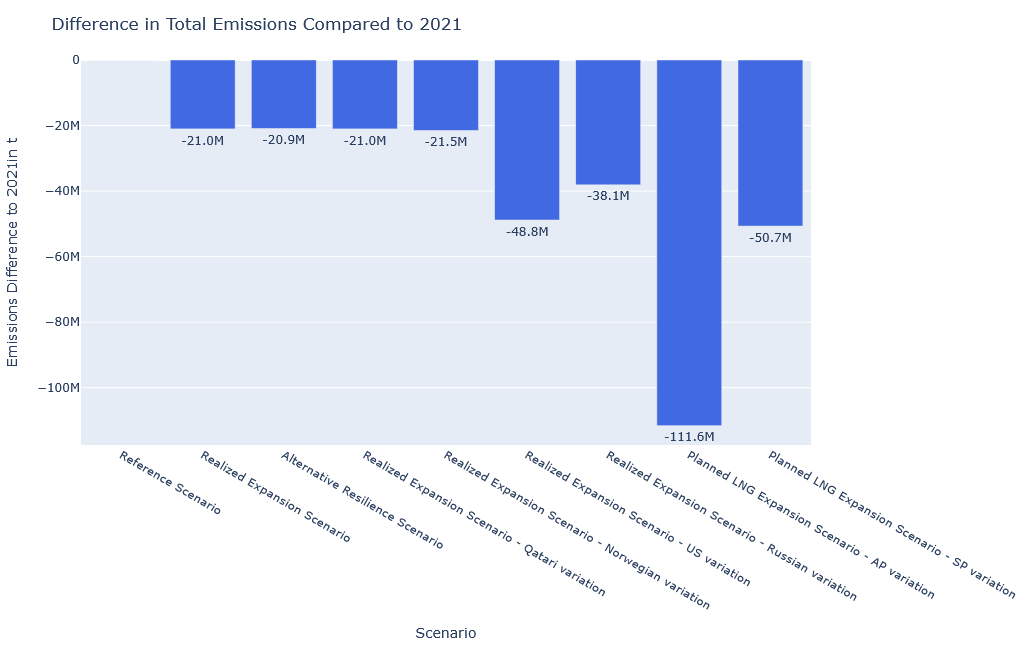

In [15]:
data_path_emissions = os.path.join(base_path, "01_data", "02_output_data", "02_unidirectional_results", "01_paper_IAEE", "02_prepared_results")
input_file_emissions= os.path.join(data_path_emissions, "emission_differences.xlsx")

emissions_diff = pd.read_excel(input_file_emissions)
emissions_diff.loc[emissions_diff['Scenario'] == '2021', 'Scenario'] = 'Reference Scenario'
emissions_diff.loc[emissions_diff['Scenario'] == '2024', 'Scenario'] = 'Realized Expansion Scenario'
emissions_diff.loc[emissions_diff['Scenario'] == '2024_no_USA', 'Scenario'] = 'Realized Expansion Scenario - US variation'
emissions_diff.loc[emissions_diff['Scenario'] == '2024_no_QA', 'Scenario'] = 'Realized Expansion Scenario - Qatari variation'
emissions_diff.loc[emissions_diff['Scenario'] == '2024_NO_red', 'Scenario'] = 'Realized Expansion Scenario - Norwegian variation'
emissions_diff.loc[emissions_diff['Scenario'] == '2024_with_RU', 'Scenario'] = 'Realized Expansion Scenario - Russian variation'
emissions_diff.loc[emissions_diff['Scenario'] == '2024_inv', 'Scenario'] = 'Alternative Resilience Scenario'
emissions_diff.loc[emissions_diff['Scenario'] == '2035_SP', 'Scenario'] = 'Planned LNG Expansion Scenario - SP variation'
emissions_diff.loc[emissions_diff['Scenario'] == '2035_AP', 'Scenario'] = 'Planned LNG Expansion Scenario - AP variation'  

#emissions_diff.sort_values(by='Scenario', inplace=True)

plot_emission_difference(emissions_diff, "2021",'Reference Scenario', base_path, False)


In [19]:
def plot_emission_difference(emissions_df,base_year,base_scenario, path, save): 
    # Calculate the difference in Total_Emissions to the base year 2021
    emissions_df['Emissions_Diff_to_'+base_year] = emissions_df['Total_Emissions'] - emissions_df.loc[emissions_df['Scenario'] == base_scenario, 'Total_Emissions'].values[0]
    # Set the color for all bars to royal blue
    emissions_df['Color'] = 'royalblue'

    # Increase figure width and adjust margins to avoid overlap with legend and fit all numbers
    fig_emissions = px.bar(
        emissions_df,
        x='Scenario',
        y='Emissions_Diff_to_2021',
        #title='Difference in Total Emissions Compared to ' + base_year,
        labels={'Emissions_Diff_to_2021': 'Emissions Difference to ' + base_year + 'in t', 'Year': 'Year'},
        text='Emissions_Diff_to_2021',
        color='Color',
        color_discrete_map="identity"
    )
    # Format the text to show values in millions, rounded
    fig_emissions.update_traces(
        texttemplate='%{text:.1f}M',
        textposition='outside',
        text=emissions_df['Emissions_Diff_to_'+base_year].apply(lambda x: round(x/1e6, 1))
    )
    fig_emissions.update_layout(
        uniformtext_minsize=8,
        uniformtext_mode='hide',
        width=1100,  # Wider figure
        height=650,
        margin=dict(l=60, r=60, t=60, b=60),
        legend=dict(
            x=1.02,
            y=1,
            xanchor='left',
            yanchor='top'
        )
    )

    fig_emissions.update_layout(uniformtext_minsize=8, uniformtext_mode='hide') 

    fig_emissions.show()
    if save:
        output_file = os.path.join(path, "02_plots", "Flow_Results", f"emission_difference_{base_year}.png")
        fig_emissions.write_image(output_file, width=1135, height=800, scale=2)

In [7]:
import plotly.express as px

In [17]:
# Desired order of rows
order = ['Reference Scenario', 'Realized Expansion Scenario', 'Realized Expansion Scenario - US variation', 
         'Realized Expansion Scenario - Norwegian variation', 'Realized Expansion Scenario - Qatari variation',
         'Realized Expansion Scenario - Russian variation', 'Alternative Resilience Scenario',
        'Planned LNG Expansion Scenario - SP variation', 'Planned LNG Expansion Scenario - AP variation']

# Reorder based on the order list
emissions_diff_ord = emissions_diff.set_index('Scenario').loc[order].reset_index()

emissions_diff_ord

,Scenario,Total_Import_Emissions,Total_Domestic_Emissions,Total_Emissions,Emissions_Diff_to_2021,Color
0,Reference Scenario,2.002241e+08,1.117973e+07,2.114039e+08,0.000000e+00,royalblue
1,Realized Expansion Scenario,1.799944e+08,1.038317e+07,1.903776e+08,-2.102630e+07,royalblue
2,Realized Expansion Scenario - US variation,1.523469e+08,1.023707e+07,1.625840e+08,-4.881987e+07,royalblue
3,Realized Expansion Scenario - Norwegian variation,1.800166e+08,9.895361e+06,1.899120e+08,-2.149187e+07,royalblue
4,Realized Expansion Scenario - Qatari variation,1.799904e+08,1.038317e+07,1.903736e+08,-2.103027e+07,royalblue
5,Realized Expansion Scenario - Russian variation,1.630840e+08,1.022665e+07,1.733107e+08,-3.809317e+07,royalblue
6,Alternative Resilience Scenario,1.798843e+08,1.062670e+07,1.905110e+08,-2.089284e+07,royalblue
7,Planned LNG Expansion Scenario - SP variation,1.518181e+08,8.920010e+06,1.607381e+08,-5.066571e+07,royalblue
8,Planned LNG Expansion Scenario - AP variation,9.464417e+07,5.155714e+06,9.979988e+07,-1.116040e+08,royalblue


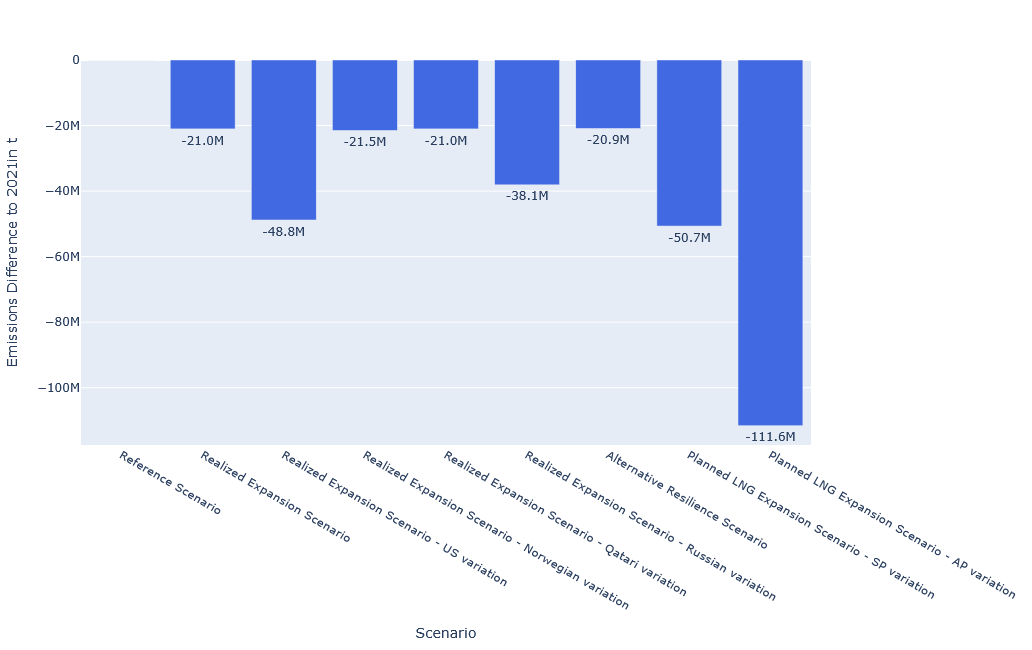

In [20]:
plot_emission_difference(emissions_diff_ord, "2021",'Reference Scenario', base_path, False)